In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ])
}

In [4]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"model": name, "accuracy": acc})

results_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False)
results_df

,model,accuracy
0,Logistic Regression,0.982456
2,SVM,0.982456
1,Random Forest,0.956140


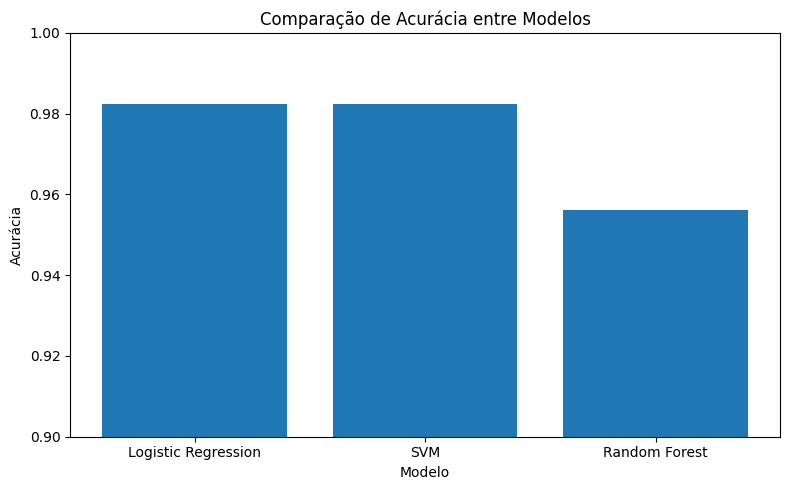

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Comparação de Acurácia entre Modelos")
plt.xlabel("Modelo")
plt.ylabel("Acurácia")
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.savefig("../figures/model_comparison.png", dpi=300)
plt.show()